# 1. Embedding Pipeline

This cell builds the first stage of the Transformer input pipeline. It defines helper functions for sentence splitting, token preprocessing, vocabulary mapping, random token embeddings, and sinusoidal positional encoding, then wraps them in `embedding_layer()` so raw text can be converted into token ids, embeddings, and position information.

In [2]:
# Embedding layer (Tokenization + Embedding + Positional Encoding)
import re
import numpy as np
import matplotlib.pyplot as plt

def split_sentences(text: str) -> list[str]:
    # Examples: "Hi! How are you?" -> ["Hi!", "How are you?"]
    chunks = re.findall(r"[^.!?]+[.!?]|[^.!?]+$", text.strip())
    return [c.strip() for c in chunks if c.strip()]

def pre_process(sentence: str) -> list[str]:
    """ normalise the sentence by makeing them lower case,
    split punctations into seprate tokens, 
    Keep punctuation tokens like ., ,, !, ?, ;, : as separate tokens
    """
    pre_process_text = sentence.lower()
    # add space around any non alphabetical characters (sepcial characters like ?!,."'@£$%^&*())
    pre_process_text = re.sub(r"([^\w\s])", r" \1 ", pre_process_text)
    # keep apostrophe contractions/possessives readable
    # e.g. sara's -> sara 's, wasn't -> was n't
    pre_process_text = re.sub(r"([a-z]+)('s|'re|'ve|'ll|'d|'m|n't)", r"\1 \2", pre_process_text)
    # cleanup extra spaces
    pre_process_text = re.sub(r"\s+", " ", pre_process_text).strip()
    pre_processed_tokens = pre_process_text.split()
    pre_processed_tokens = ["[BOS]"] + pre_processed_tokens + ["[EOS]"]
      
    return pre_processed_tokens


def tokenize(text: str) -> list[str]:
    """Split text into sentences, tokenize each, and combine all tokens."""
    sentences = split_sentences(text)
    all_tokens = []
    for sentence in sentences:
        tokens = pre_process(sentence)  # Tokenize each sentence
        all_tokens.extend(tokens)       # Combine all tokens into one list
    return all_tokens

def token_index_mapping(tokens: list[str]) -> dict[str, int]:
    "build a mapping from all my tokens to a unique index"
    mapping = {token: idx for idx, token in enumerate(set(tokens))}
    return mapping

def token_to_index(tokens: list[str], mapping:dict[str, int]) -> list[int]:
    "coverts tokens to their corresponding index value"
    return [mapping[token] for token in tokens]
    


def initialized_embedding_vector(mapping: dict[str, int], embedding_dim: int=50) -> np.ndarray:
    """create an embedding matrix where each row corresponds to a tokens vector representations.
    learned relationships between works
    all this function does randlomly initialise the emebeddings - the embeddings later is going to be learned
    later in the process Token IDs -> embeddings -> positional encoding added -> attention + feed-forward blocks -> logits
    as you can see we are not bringing the text yet, this just initial embeddings based on mapping
    
    embedding_dim: the length of each token vector, depending of the dataset size
    If vocab size is V and embedding_dim is d, embedding matrix shape is V x d.
    0.01 to make the initial values too small
    """
    mapping_size = len(mapping)
    embedding_matrix = np.random.randn(mapping_size, embedding_dim) * 0.01
    return embedding_matrix

def positional_encoding(seq_len: int, output_dimension: int, n: int=1000):
    """
    this calculated the postional encoding  matrix
    where k is the position of the world which is between 0<= k <= seq_len
    d = is the dimention of the embedding output -> must be and even number
    (because the format of embedding matrix. i=0->sin, i=0 -> cos)
    n  =  bye default is 1000 accoring to the attention is all you need papaer
    however this value controls the frequency range used in sin,cos
    bigger n -> slower changing(aka longer waves) -> this allows to the embedding to
    represent both long and short seq lenght
    i = is frequency index 0<= i <= d/2  
    2i(sin) (odd), 2i+1(cos)(even) = embedding corrdinated 
    PE(k, j) -> value of row k in column j
    """
    if output_dimension%2 !=0:
        return ValueError("Dimension of the output matrix must be even number")
    positional_encoding_matrix = np.zeros((seq_len, output_dimension))
    for k in range(seq_len):
        for i in np.arange(int(output_dimension/2)):
            denominator = np.power(n, 2*i/output_dimension)
            positional_encoding_matrix[k, 2*i] = np.sin(k/denominator)
            positional_encoding_matrix[k, 2*i+1] = np.cos(k/denominator)
    return positional_encoding_matrix


def plotSinusoid(k, d=512, n=10000):
    """
    Plot a sinusoidal positional encoding channel for a given position.

    Parameters
    ----------
    k : int
        The position index (token position in the sequence) to visualize.
    d : int, optional
        The embedding dimension (default: 512). Controls the range of frequencies.
    n : int, optional
        The scaling factor for frequency (default: 10000). Higher n means slower-changing waves.

    Description
    -----------
    This function plots the values of the sinusoidal positional encoding for a fixed position k
    across different frequency indices (x-axis). It visualizes how the encoding changes as the
    frequency index increases, showing the effect of the denominator n^(2x/d) in the formula.

    Example
    -------
    plotSinusoid(0)
    plotSinusoid(10, d=16)
    """
    x = np.arange(0, 100, 1)
    denominator = np.power(n, 2*x/d)
    y = np.sin(k/denominator)
    plt.plot(x, y)
    plt.title('k = ' + str(k))

def embedding_layer(text, embedding_dim=64):
    """
    Complete embedding layer: tokenization, mapping, token ids, embedding matrix, and positional encoding.

    Parameters
    ----------
    sentence : str
        Input sentence to process.
    embedding_dim : int, optional
        Dimension of the embedding and positional encoding (default: 64, must be even).

    Returns
    -------
    tokens : list[str]
        List of tokens after tokenization.
    mapping : dict
        Token-to-index mapping.
    indices : list[int]
        List of token indices.
    embedding_matrix : np.ndarray
        Randomly initialized embedding matrix (vocab_size x embedding_dim).
    pe_matrix : np.ndarray
        Positional encoding matrix (sequence_length x embedding_dim).
    """
    tokens = tokenize(text)
    mapping = token_index_mapping(tokens)
    indices = token_to_index(tokens, mapping)
    embedding_matrix = initialized_embedding_vector(mapping, embedding_dim)
    posiotinal_embedding_matrix = positional_encoding(seq_len=len(tokens), output_dimension=embedding_dim)
    return tokens, mapping, indices, embedding_matrix, posiotinal_embedding_matrix



# TODO:: create a config for Embedding
# TODO:: maybe convert this to a class of embedding matrix.... or like a module



# 2. Visualising Positional Encoding

This cell uses a sample sentence to run the embedding pipeline and then plots the sinusoidal positional encoding. The goal is to make the abstract position vectors visible so you can see how token positions are represented across embedding dimensions.

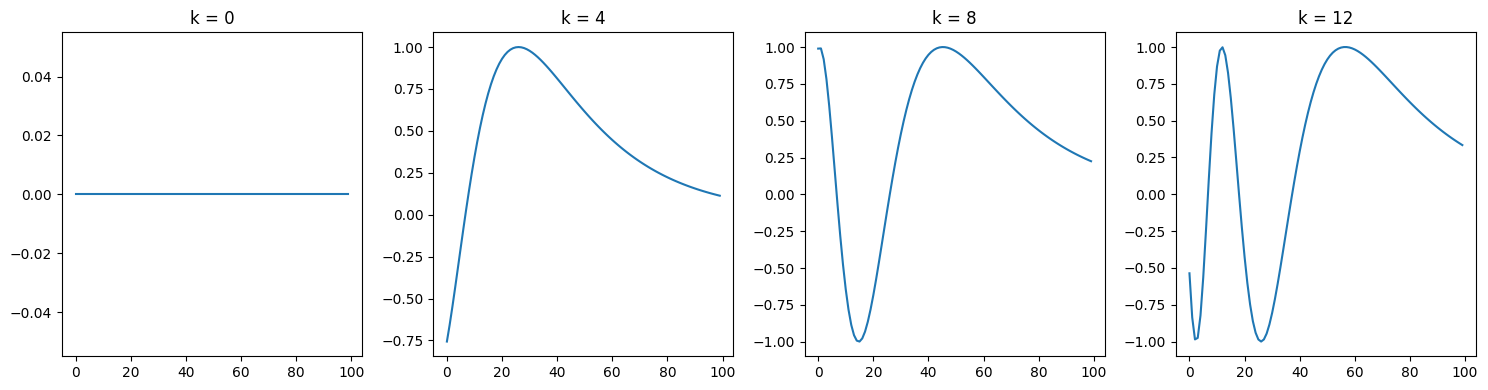

<Figure size 1000x600 with 0 Axes>

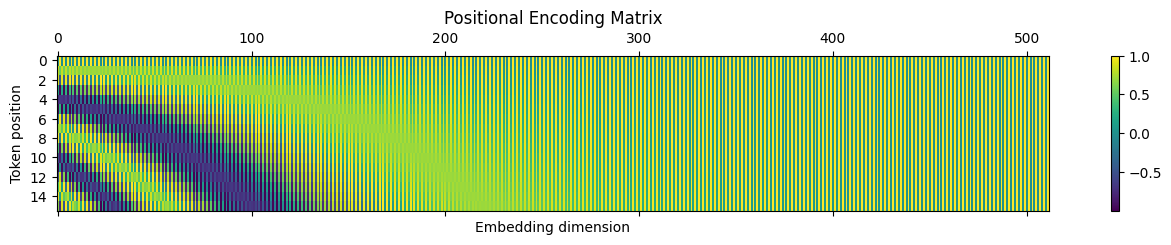

In [5]:
sentence = "Hey! The kitten chased the butterfly because it was playful."
output_dimension = 512

tokens = tokenize(sentence)
# print(tokens)
# mapping = token_index_mapping(tokens)
# print(mapping)
# indices = token_to_index(tokens, mapping)
# print(indices)
# initial_embedding_matrix = initialized_embedding_vector(mapping)
# # print(initial_embedding_matrix)
# pe_matrix = positional_encoding(seq_len = len(tokens), output_dimension = output_dimension)
# # print(pe_matrix)
tokens, mapping, indices, embedding_matrix, pe_matrix = embedding_layer(text= sentence, embedding_dim=output_dimension)


fig = plt.figure(figsize=(15, 4))
N = min(4, len(tokens))  # Show up to 4 subplots
for i in range(N):
    plt.subplot(1, N, i+1)
    plotSinusoid(i*4, output_dimension)
plt.tight_layout()
plt.show()

# visulaise the positional endcoding matrix
plt.figure(figsize=(10, 6))
cax = plt.matshow(pe_matrix, aspect='auto', cmap='viridis')
plt.colorbar(cax)
plt.xlabel("Embedding dimension")
plt.ylabel("Token position")
plt.title("Positional Encoding Matrix")
plt.show()

# 3. Scaled Dot-Product Attention

This cell implements the core attention equation from the Transformer paper: `softmax(QK^T / sqrt(d_k))V`. It returns both the attention output and the attention weights so you can inspect what each token attends to.

In [1]:
# Multi-Head Attention 

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch_size, seq_len_q, d_k)
    K: (batch_size, seq_len_k, d_k)
    V: (batch_size, seq_len_k, d_v)
    mask: (batch_size, seq_len_q, seq_len_k) or None

    Returns:
        output: (batch_size, seq_len_q, d_v)
        attention_weights: (batch_size, seq_len_q, seq_len_k)
    """
    d_k = Q.shape[-1] # to get the dimensions of Q,K, and V
    # (batch_size, seq_len_q, seq_len_k)
    scores = np.matmul(Q, K.transpose(0, 2, 1))/np.sqrt(d_k)
    if mask is not None:
         # mask == 0 means masked, so set those positions to a large negative value
          scores = np.where(mask, scores, -1e9)
    # Softmax along last axis (keys)
    attention_weights = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    attention_weights = attention_weights / np.sum(attention_weights, axis=-1, keepdims=True)
    # Weighted sum of V
    output = np.matmul(attention_weights, V)
    return output, attention_weights

# 4. Self-Attention Example

This cell creates a tiny example sentence, turns the token embeddings into queries, keys, and values, and runs the scaled dot-product attention function. It is a concrete demonstration of what attention does before multi-head splitting is introduced.

In [9]:
sentence = "Hello world!"
tokens, mapping, indices, embedding_matrix, pe_matrix = embedding_layer(text=sentence, embedding_dim=output_dimension)
# Get token embeddings for your sentence
token_embeddings = embedding_matrix[indices]  # shape: (seq_len, embedding_dim)
# Add positional encoding
input_embeddings = token_embeddings + pe_matrix  # shape: (seq_len, embedding_dim)

# Reshape for batch dimension (batch_size=1) 
# batch size represents the number of independent sequences (sentences, token lists, etc.)
# bach allows to process multiple smaples at once for efficency example 32 sentence at once
Q = K = V = input_embeddings[np.newaxis, :, :]  # shape: (1, seq_len, embedding_dim)
output, attn_weights = scaled_dot_product_attention(Q, K, V)
# Print Q, K, V for inspection
print("Tokens:", tokens)
print("Q (Query vectors):\n", Q[0])  # Remove batch dimension for readability
print("K (Key vectors):\n", K[0])
print("V (Value vectors):\n", V[0])

print("Attention output:", output)
print("Attention weights:", attn_weights)

Tokens: ['[BOS]', 'hello', 'world', '!', '[EOS]']
Q (Query vectors):
 [[-0.00187782  0.99835902 -0.00158166 ...  1.00318905 -0.0015567
   0.99979589]
 [ 0.83857898  0.52366134  0.83869805 ...  0.99779775 -0.00119081
   1.00346161]
 [ 0.90317178 -0.42092078  0.9181429  ...  1.00189439 -0.0025435
   1.00177032]
 [ 0.13856715 -1.00036477  0.22008357 ...  1.01060586  0.02019866
   0.98387056]
 [-0.76573176 -0.65426822 -0.67206443 ...  1.00307539 -0.00695887
   0.9958903 ]]
K (Key vectors):
 [[-0.00187782  0.99835902 -0.00158166 ...  1.00318905 -0.0015567
   0.99979589]
 [ 0.83857898  0.52366134  0.83869805 ...  0.99779775 -0.00119081
   1.00346161]
 [ 0.90317178 -0.42092078  0.9181429  ...  1.00189439 -0.0025435
   1.00177032]
 [ 0.13856715 -1.00036477  0.22008357 ...  1.01060586  0.02019866
   0.98387056]
 [-0.76573176 -0.65426822 -0.67206443 ...  1.00307539 -0.00695887
   0.9958903 ]]
V (Value vectors):
 [[-0.00187782  0.99835902 -0.00158166 ...  1.00318905 -0.0015567
   0.99979589]
 [ 0

# 5. Inspecting Keys and Values

This cell prints each token alongside part of its key and value vectors. The purpose is to connect the mathematical tensors back to the original tokens and make the attention inputs easier to reason about.

In [12]:
print("Token (string) and Key vector (first 5 dims):")
for token, key_vec in zip(tokens, K[0]):
    print(f"{token:>8}: {key_vec[:5]}")

print("\n\n\n")
for token, value_vec in zip(tokens, V[0]):
    print(f"{token:>8}: {value_vec[:5]}")    

Token (string) and Key vector (first 5 dims):
   [BOS]: [-0.00187782  0.99835902 -0.00158166  1.00413596  0.00806526]
   hello: [0.83857898 0.52366134 0.83869805 0.56954733 0.82303584]
   world: [ 0.90317178 -0.42092078  0.9181429  -0.36612497  0.94418057]
       !: [ 0.13856715 -1.00036477  0.22008357 -0.9734399   0.31637148]
   [EOS]: [-0.76573176 -0.65426822 -0.67206443 -0.72909456 -0.60345465]




   [BOS]: [-0.00187782  0.99835902 -0.00158166  1.00413596  0.00806526]
   hello: [0.83857898 0.52366134 0.83869805 0.56954733 0.82303584]
   world: [ 0.90317178 -0.42092078  0.9181429  -0.36612497  0.94418057]
       !: [ 0.13856715 -1.00036477  0.22008357 -0.9734399   0.31637148]
   [EOS]: [-0.76573176 -0.65426822 -0.67206443 -0.72909456 -0.60345465]


# 6. Multi-Head Attention Class

This cell turns the single-head attention idea into a reusable multi-head attention module. It learns projection matrices for queries, keys, values, and the output, then splits the hidden dimension across heads, runs attention head-by-head, and combines the results back together.

In [41]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        """
        d_model: total embedding dimension
        num_heads: number of attention heads
        """
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model=d_model
        self.num_heads=num_heads
        self.d_head = d_model // num_heads


        # Intialize the weights for Q,K and V and output projection
        self.w_q = np.random.randn(d_model, d_model) * 0.01
        self.w_k = np.random.randn(d_model, d_model) * 0.01
        self.w_v = np.random.randn(d_model, d_model) * 0.01
        self.w_o = np.random.randn(d_model, d_model) * 0.01

    def split_heads(self, X):
        """
        Splits the last dimension of the input tensor into (num_heads, d_head) and rearranges the axes
        so that each attention head can be processed in parallel.
    
        Parameters
        ----------
        X : np.ndarray
            Input tensor of shape (batch_size, seq_len, d_model).
    
        Returns
        -------
        np.ndarray
        Output tensor of shape (batch_size, num_heads, seq_len, d_head), where d_head = d_model // num_heads.
        """
        # X: (batch_size, seq_len, d_model)
        batch_size, seq_len, _ = X.shape
        X = X.reshape(batch_size,seq_len, self.num_heads, self.d_head)
        return X.transpose(0,2,1,3) # (batch_size, num_heads, seq_len, d_head)
    
    def combine_heads(self, X):
        """
        Combines the multi-head outputs back into a single tensor by reversing the split_heads operation.

        Parameters
        ----------
        X : np.ndarray
            Input tensor of shape (batch_size, num_heads, seq_len, d_head).

        Returns
        -------
        np.ndarray
            Output tensor of shape (batch_size, seq_len, d_model), where d_model = num_heads * d_head.
        """
        # X: (batch_size, num_heads, seq_len, d_head)
        batch_size, num_heads, seq_len, d_head = X.shape
        X = X.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, num_heads * d_head)
        return X
    
    def forward(self, X, mask=None, K=None, V=None):
       """
       X: (batch_size, seq_len, d_model) - always used for Q
       K: (batch_size, seq_len_k, d_model) - if None, use X (self-attention)
       V: (batch_size, seq_len_k, d_model) - if None, use X (self-attention)
       mask: (batch_size, seq_len_q, seq_len_k) or None
       """
       if K is None:
           K = X
       if V is None:
           V = X
       Q = X @ self.w_q
       K_proj = K @ self.w_k
       V_proj = V @ self.w_v

       Q = self.split_heads(Q)
       K_proj = self.split_heads(K_proj)
       V_proj = self.split_heads(V_proj)

       outputs = []
       attn_weights = []
       for h in range(self.num_heads):
           out, attn = scaled_dot_product_attention(Q[:, h], K_proj[:, h], V_proj[:, h], mask)
           outputs.append(out)
           attn_weights.append(attn)
       outputs = np.stack(outputs, axis=1)
       attn_weights = np.stack(attn_weights, axis=1)
       concat = self.combine_heads(outputs)
       output = concat @ self.w_o
       return output, attn_weights

# 7. Add & LayerNorm

This cell implements the residual connection plus layer normalization block used throughout the Transformer. It takes the original input, adds the sublayer output, and normalizes the result to keep training stable and preserve information flow.

In [36]:
#  implement Add & LayerNorm (residual connection + normalization)
import numpy as np

class AddNorm:
    def __init__(self, d_model, eps=1e-6):
        """
        Add & LayerNorm module for transformers.

        Parameters
        ----------
        d_model : int
            The feature dimension (embedding size).
        eps : float, optional
            Small value to avoid division by zero (default: 1e-6).
        """
        self.gamma = np.ones((d_model,))
        self.beta = np.zeros((d_model,))
        self.eps = eps

    def layer_norm(self, X):
        """
        Applies layer normalization over the last dimension.

        Parameters
        ----------
        X : np.ndarray
            Input tensor of shape (..., d_model).

        Returns
        -------
        np.ndarray
            Layer-normalized tensor, same shape as X.
        """
        mean = X.mean(axis=-1, keepdims=True)
        var = X.var(axis=-1, keepdims=True)
        normed = (X - mean) / np.sqrt(var + self.eps)
        return self.gamma * normed + self.beta

    def __call__(self, X, sublayer_out):
        """
        Residual connection + LayerNorm.

        Parameters
        ----------
        X : np.ndarray
            Input tensor (residual), shape (..., d_model).
        sublayer_out : np.ndarray
            Output from the sublayer, same shape as X.

        Returns
        -------
        np.ndarray
            Output after residual connection and layer normalization.
        """
        return self.layer_norm(X + sublayer_out)

# 8. Add & LayerNorm Example

This cell tests the `AddNorm` class with small dummy tensors. It is just a sanity-check example so you can verify the shape and numerical behavior of the residual-plus-normalization step.

In [37]:
# Dummy input: batch_size=2, seq_len=3, d_model=4
X = np.array([
    [[1.0, 2.0, 3.0, 4.0],
     [2.0, 3.0, 4.0, 5.0],
     [3.0, 4.0, 5.0, 6.0]],
    [[0.5, 1.5, 2.5, 3.5],
     [1.5, 2.5, 3.5, 4.5],
     [2.5, 3.5, 4.5, 5.5]]
])

# Dummy sublayer output (same shape)
sublayer_out = np.array([
    [[0.1, 0.2, 0.3, 0.4],
     [0.2, 0.3, 0.4, 0.5],
     [0.3, 0.4, 0.5, 0.6]],
    [[0.05, 0.15, 0.25, 0.35],
     [0.15, 0.25, 0.35, 0.45],
     [0.25, 0.35, 0.45, 0.55]]
])

add_norm = AddNorm(d_model=4)
print(add_norm)
output = add_norm(X, sublayer_out)
print("Output after Add & LayerNorm:\n", output)


Output after Add & LayerNorm:
 [[[-1.34164034 -0.44721345  0.44721345  1.34164034]
  [-1.34164034 -0.44721345  0.44721345  1.34164034]
  [-1.34164034 -0.44721345  0.44721345  1.34164034]]

 [[-1.34164034 -0.44721345  0.44721345  1.34164034]
  [-1.34164034 -0.44721345  0.44721345  1.34164034]
  [-1.34164034 -0.44721345  0.44721345  1.34164034]]]


# 9. Position-wise Feed-Forward Network

This cell implements the Transformer feed-forward network applied independently at each token position. It uses two linear layers with a ReLU nonlinearity in between, which is the second major sublayer inside each encoder and decoder block.

In [38]:
# implement Feed-Forward Network (FFN)
import numpy as np

class PositionwiseFFN:
    def __init__(self, d_model, d_ff):
        """
        Position-wise Feed-Forward Network (FFN) for transformers.

        Parameters
        ----------
        d_model : int
            Input and output feature dimension (embedding size).
        d_ff : int
            Hidden layer size (usually 4 * d_model).
        """
        # Initialize weights and biases
        self.W1 = np.random.randn(d_model, d_ff) * 0.01
        self.b1 = np.zeros((d_ff,))
        self.W2 = np.random.randn(d_ff, d_model) * 0.01
        self.b2 = np.zeros((d_model,))

    def __call__(self, X):
        """
        Applies the FFN to the input.

        Parameters
        ----------
        X : np.ndarray
            Input tensor of shape (batch_size, seq_len, d_model).

        Returns
        -------
        np.ndarray
            Output tensor of shape (batch_size, seq_len, d_model).
        """
        # First linear layer + ReLU
        out1 = np.dot(X, self.W1) + self.b1  # (batch_size, seq_len, d_ff)
        out1 = np.maximum(0, out1)           # ReLU activation
        # Second linear layer
        out2 = np.dot(out1, self.W2) + self.b2  # (batch_size, seq_len, d_model)
        return out2

# 10. Encoder Layer

This cell assembles a full encoder block by combining self-attention, residual add-norm, the feed-forward network, and another add-norm step. It is your first full Transformer layer built from the smaller pieces defined above.

In [39]:
# implement decoder and encoder
class EncoderLayer:
    def __init__(self, d_model, num_heads, d_ff):
        """
        Transformer Encoder Layer.

        Parameters
        ----------
        d_model : int
            Embedding dimension.
        num_heads : int
            Number of attention heads.
        d_ff : int
            Hidden size of the feed-forward network.
        """
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model)
        self.ffn = PositionwiseFFN(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model)

    def __call__(self, X, mask=None):
        """
        Forward pass for the encoder layer.

        Parameters
        ----------
        X : np.ndarray
            Input tensor of shape (batch_size, seq_len, d_model).
        mask : np.ndarray or None
            Optional attention mask.

        Returns
        -------
        np.ndarray
            Output tensor of shape (batch_size, seq_len, d_model).
        np.ndarray
            Attention weights of shape (batch_size, num_heads, seq_len, seq_len).
        """
        # Self-attention + Add & Norm
        attn_out, attn_weights = self.self_attn.forward(X, mask)
        out1 = self.add_norm1(X, attn_out)
        # Feed-forward + Add & Norm
        ffn_out = self.ffn(out1)
        out2 = self.add_norm2(out1, ffn_out)
        return out2, attn_weights

# 11. Encoder Example

This cell creates a simple embedded sentence and sends it through the encoder layer. It checks that the encoder produces the expected output shape and attention-weight shape for a single batch.

In [40]:
# Suppose output_dimension = d_model (e.g., 512)
d_model = output_dimension
num_heads = 8
d_ff = 4 * d_model

# Prepare input (already done)
sentence = "Hello world!"
tokens, mapping, indices, embedding_matrix, pe_matrix = embedding_layer(text=sentence, embedding_dim=d_model)
token_embeddings = embedding_matrix[indices]  # (seq_len, d_model)
input_embeddings = token_embeddings + pe_matrix  # (seq_len, d_model)
X = input_embeddings[np.newaxis, :, :]  # (1, seq_len, d_model)

# Create encoder layer
encoder_layer = EncoderLayer(d_model=d_model, num_heads=num_heads, d_ff=d_ff)

# Forward pass through encoder layer
output, attn_weights = encoder_layer(X)

print("Encoder output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)

Encoder output shape: (1, 5, 512)
Attention weights shape: (1, 8, 5, 5)


# 12. Decoder Layer

This cell defines a decoder block with masked self-attention, cross-attention over the encoder output, and a feed-forward network. It also includes the causal mask used to prevent the decoder from looking at future target tokens.

In [42]:
class DecoderLayer:
    def __init__(self, d_model, num_heads, d_ff):
        self.self_attn = MultiHeadAttention(d_model, num_heads)      # Masked self-attention
        self.add_norm1 = AddNorm(d_model)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)     # Cross-attention
        self.add_norm2 = AddNorm(d_model)
        self.ffn = PositionwiseFFN(d_model, d_ff)
        self.add_norm3 = AddNorm(d_model)

    def generate_subsequent_mask(self, seq_len):
        # Causal mask: True where allowed, False where masked
        mask = np.triu(np.ones((seq_len, seq_len)), k=1).astype(bool)
        return ~mask  # (seq_len, seq_len)

    def __call__(self, X, enc_output, tgt_mask=None, memory_mask=None):
        """
        X: (batch_size, tgt_seq_len, d_model) - decoder input
        enc_output: (batch_size, src_seq_len, d_model) - encoder output
        tgt_mask: (batch_size, tgt_seq_len, tgt_seq_len) or None
        memory_mask: (batch_size, tgt_seq_len, src_seq_len) or None
        """
        batch_size, tgt_seq_len, _ = X.shape

        # Masked self-attention (causal mask)
        if tgt_mask is None:
            mask = self.generate_subsequent_mask(tgt_seq_len)[np.newaxis, :, :]
        else:
            mask = tgt_mask
        self_attn_out, attn_weights_self = self.self_attn.forward(X, mask)

        out1 = self.add_norm1(X, self_attn_out)

        # Cross-attention (decoder attends to encoder output)
        cross_attn_out, attn_weights_cross = self.cross_attn.forward(
            out1, memory_mask, K=enc_output, V=enc_output
        )
        out2 = self.add_norm2(out1, cross_attn_out)

        # Feed-forward + Add & Norm
        ffn_out = self.ffn(out2)
        out3 = self.add_norm3(out2, ffn_out)

        return out3, attn_weights_self, attn_weights_cross

# 13. Encoder-Decoder Example

This cell runs a miniature end-to-end example: first the source sentence is encoded, then a target sentence is passed through the decoder with cross-attention over the encoder memory. It is the first concrete demonstration of the full seq2seq flow.

In [44]:
# --- ENCODER ---
src_sentence = "Hello world!"
tokens, mapping, indices, embedding_matrix, pe_matrix = embedding_layer(text=src_sentence, embedding_dim=d_model)
token_embeddings = embedding_matrix[indices]
input_embeddings = token_embeddings + pe_matrix
X = input_embeddings[np.newaxis, :, :]  # (1, src_seq_len, d_model)

encoder_layer = EncoderLayer(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
encoder_output, _ = encoder_layer(X)  # (1, src_seq_len, d_model)

print("Encoder output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)

# --- DECODER ---
tgt_sentence = "Hi world !"  # Example target sequence
tgt_tokens, tgt_mapping, tgt_indices, tgt_embedding_matrix, tgt_pe_matrix = embedding_layer(
    text=tgt_sentence, embedding_dim=d_model
)
tgt_token_embeddings = tgt_embedding_matrix[tgt_indices]
tgt_input_embeddings = tgt_token_embeddings + tgt_pe_matrix
Y = tgt_input_embeddings[np.newaxis, :, :]  # (1, tgt_seq_len, d_model)

decoder_layer = DecoderLayer(d_model=d_model, num_heads=num_heads, d_ff=d_ff)
decoder_output, attn_weights_self, attn_weights_cross = decoder_layer(
    Y, encoder_output
)

print("Decoder output shape:", decoder_output.shape)
print("Self-attention weights shape:", attn_weights_self.shape)
print("Cross-attention weights shape:", attn_weights_cross.shape)

Encoder output shape: (1, 5, 512)
Attention weights shape: (1, 8, 5, 5)
Decoder output shape: (1, 5, 512)
Self-attention weights shape: (1, 8, 5, 5)
Cross-attention weights shape: (1, 8, 5, 5)


# 14. NumPy Transformer Assembly

This cell wraps the encoder, decoder, embeddings, and output projection into a simple Transformer class. It is still a conceptual NumPy implementation, so it can produce probabilities but it is not yet trainable with backpropagation.

In [45]:
#  implement assemble transformer and train
class Transformer:
    def __init__(self, d_model, num_heads, d_ff):
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_ff = d_ff
        self.encoder = EncoderLayer(d_model, num_heads, d_ff)
        self.decoder = DecoderLayer(d_model, num_heads, d_ff)
        # Output projection (will be set after seeing target vocab)
        self.W_out = None
        self.b_out = None
        self.tgt_vocab = None

    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return e_x / np.sum(e_x, axis=-1, keepdims=True)

    def embedding_and_pe(self, text, embedding_dim):
        tokens, mapping, indices, embedding_matrix, pe_matrix = embedding_layer(
            text=text, embedding_dim=embedding_dim
        )
        token_embeddings = embedding_matrix[indices]
        input_embeddings = token_embeddings + pe_matrix
        return tokens, mapping, indices, input_embeddings, embedding_matrix, pe_matrix

    def __call__(self, src_text, tgt_text):
        # --- Source embedding ---
        src_tokens, src_mapping, src_indices, src_input_embeddings, src_embedding_matrix, src_pe_matrix = \
            self.embedding_and_pe(src_text, self.d_model)
        src_X = src_input_embeddings[np.newaxis, :, :]  # (1, src_seq_len, d_model)

        # --- Target embedding ---
        tgt_tokens, tgt_mapping, tgt_indices, tgt_input_embeddings, tgt_embedding_matrix, tgt_pe_matrix = \
            self.embedding_and_pe(tgt_text, self.d_model)
        tgt_X = tgt_input_embeddings[np.newaxis, :, :]  # (1, tgt_seq_len, d_model)

        # Set output projection if not already set
        if (self.W_out is None) or (self.tgt_vocab is None) or (self.tgt_vocab != tgt_mapping):
            self.W_out = np.random.randn(self.d_model, len(tgt_mapping)) * 0.01
            self.b_out = np.zeros((len(tgt_mapping),))
            self.tgt_vocab = tgt_mapping

        # --- Encoder ---
        enc_output, _ = self.encoder(src_X)

        # --- Decoder ---
        dec_output, _, _ = self.decoder(tgt_X, enc_output)

        # --- Output projection ---
        logits = np.dot(dec_output, self.W_out) + self.b_out  # (1, tgt_seq_len, vocab_size)
        probs = self.softmax(logits)
        return probs, tgt_tokens, self.tgt_vocab

# 15. Cross-Entropy Loss Function

This cell defines a cross-entropy helper that measures how well the model’s predicted probabilities match the true target tokens. It introduces the loss function you need before training can be added.

In [47]:
def cross_entropy(probs, target_indices):
    """
    probs: (1, seq_len, vocab_size) - output from the model
    target_indices: (seq_len,) - list/array of true token indices for each position
    Returns: average negative log likelihood (scalar)
    """
    eps = 1e-9  # to avoid log(0)
    # For each position, pick the probability of the correct token
    log_probs = -np.log(probs[0, np.arange(len(target_indices)), target_indices] + eps)
    return np.mean(log_probs)

# 16. NumPy Transformer Demo

This cell instantiates the simple NumPy Transformer and runs it on a toy source-target pair. It is a final forward-pass demo that shows the model output shape, target tokens, and the target vocabulary mapping.

In [46]:
# Example usage:
d_model = 512
num_heads = 8
d_ff = 4 * d_model

transformer = Transformer(d_model, num_heads, d_ff)
src_sentence = "Hello world!"
tgt_sentence = "Hi world !"

probs, tgt_tokens, tgt_vocab = transformer(src_sentence, tgt_sentence)
print("Output probabilities shape:", probs.shape)  # (1, tgt_seq_len, tgt_vocab_size)
print("Target tokens:", tgt_tokens)
print("Target vocab mapping:", tgt_vocab)

Output probabilities shape: (1, 5, 5)
Target tokens: ['[BOS]', 'hi', 'world', '!', '[EOS]']
Target vocab mapping: {'world': 0, '[EOS]': 1, '[BOS]': 2, '!': 3, 'hi': 4}


# Part 2 — Making the Transformer Trainable with PyTorch

The NumPy cells above already explain the Transformer building blocks well. In this section we keep that structure, but switch the trainable path to **PyTorch `nn.Module`** so we can use **autograd** and optimize parameters with gradient descent.

This section now does three things:

- Reuses your earlier **tokenization idea** and **sinusoidal positional encoding formula**
- Trains a small **English -> Persian** encoder-decoder Transformer
- Trains a **decoder-only next-token model** for language modelling

### What is reused vs replaced

| Component | Existing notebook implementation | Trainable version used here |
|---|---|---|
| Token preprocessing | `pre_process()` | reused through a wrapper helper |
| Positional encoding formula | `positional_encoding()` | reused to build a Torch buffer |
| Attention / encoder / decoder logic | your NumPy classes | replaced with `nn.Transformer*` because NumPy code does not support automatic differentiation |
| Training loop | not present yet | added with optimizer + backprop |

The reason I did not directly train the NumPy attention classes is simple: they do not have a gradient system, parameter registration, or optimizer integration. For training, that is the missing piece.

## 17. Trainable Utilities for the PyTorch Version

This cell imports the training libraries and defines the vocabulary helper used by the trainable part of the notebook. It also reuses your earlier preprocessing logic through a wrapper so the training pipeline stays consistent with the study pipeline above.

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ── Reuse notebook preprocessing when available ──────────────────────────────
# The study cells above already define pre_process().
# We reuse it here so the trainable section stays aligned with your notebook.

def trainable_tokenize(text: str) -> list[str]:
    if "pre_process" in globals():
        tokens = pre_process(text)
        return [t for t in tokens if t not in ("[BOS]", "[EOS]")]

    text = text.lower()
    text = re.sub(r"([^\w\s])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


# ── Vocabulary helper ─────────────────────────────────────────────────────────
# Special tokens are kept separate from your study tokenizer so the dataset,
# decoder input, and loss targets are controlled explicitly during training.

class Vocabulary:
    PAD, UNK, BOS, EOS = "<PAD>", "<UNK>", "<BOS>", "<EOS>"

    def __init__(self):
        self.token2idx: dict[str, int] = {}
        self.idx2token: dict[int, str] = {}
        for tok in [self.PAD, self.UNK, self.BOS, self.EOS]:
            self._add(tok)

    def _add(self, token: str):
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    def build(self, sentences: list[str]):
        for sentence in sentences:
            for token in trainable_tokenize(sentence):
                self._add(token)

    def encode(self, sentence: str, add_bos=True, add_eos=True) -> list[int]:
        tokens = trainable_tokenize(sentence)
        if add_bos:
            tokens = [self.BOS] + tokens
        if add_eos:
            tokens = tokens + [self.EOS]
        unk_idx = self.token2idx[self.UNK]
        return [self.token2idx.get(token, unk_idx) for token in tokens]

    def decode(self, indices: list[int]) -> list[str]:
        return [self.idx2token.get(i, self.UNK) for i in indices]

    def __len__(self):
        return len(self.token2idx)


print("Vocabulary helper ready.")

## 18. Trainable Positional Encoding and Transformer Model

This cell rebuilds the positional encoding and encoder-decoder architecture as PyTorch modules. It keeps the same Transformer structure conceptually, but switches to `nn.Module` and built-in Transformer layers so parameters can be trained with automatic differentiation.

In [ ]:
# ── Positional Encoding (PyTorch) ─────────────────────────────────────────────
# Reuses your earlier sinusoidal positional_encoding() implementation and stores
# the result as a Torch buffer so it participates in the forward pass but is not trained.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        if "positional_encoding" in globals():
            pe_np = positional_encoding(seq_len=max_len, output_dimension=d_model, n=10000)
            pe = torch.tensor(pe_np, dtype=torch.float32)
        else:
            pe = torch.zeros(max_len, d_model)
            pos = torch.arange(0, max_len).unsqueeze(1).float()
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div)
            pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ── Encoder-Decoder Transformer (for translation) ────────────────────────────
# The conceptual structure is still the same as your study version:
# embedding -> positional encoding -> encoder -> decoder -> output projection
# We use PyTorch's built-in transformer layers so the model is trainable.

class TransformerModel(nn.Module):
    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int = 64,
        num_heads: int = 4,
        num_enc_layers: int = 2,
        num_dec_layers: int = 2,
        d_ff: int = 256,
        max_seq_len: int = 128,
        dropout: float = 0.1,
        src_pad_idx: int = 0,
        tgt_pad_idx: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=src_pad_idx)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=tgt_pad_idx)
        self.pos_enc = PositionalEncoding(d_model, max_seq_len, dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model, num_heads, d_ff, dropout, batch_first=True, norm_first=False
        )
        dec_layer = nn.TransformerDecoderLayer(
            d_model, num_heads, d_ff, dropout, batch_first=True, norm_first=False
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_enc_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, num_dec_layers)
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        for parameter in self.parameters():
            if parameter.dim() > 1:
                nn.init.xavier_uniform_(parameter)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        device = src.device
        src_pad_mask = src == self.src_pad_idx
        tgt_pad_mask = tgt == self.tgt_pad_idx
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1), device=device)

        src_emb = self.pos_enc(self.src_emb(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.tgt_emb(tgt) * math.sqrt(self.d_model))

        memory = self.encoder(src_emb, src_key_padding_mask=src_pad_mask)
        decoded = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.output_proj(decoded)


print("Trainable TransformerModel defined.")

## 19. English to Persian Dataset Setup

This cell creates a small English-Persian toy dataset, builds source and target vocabularies, and defines the dataset plus collate function used by the DataLoader. It is the data preparation stage for translation training.

In [ ]:
# ── Translation Dataset (EN → FA) ─────────────────────────────────────────────
# Small hand-crafted pairs for a trainable English -> Persian example.
# Persian is written right-to-left, but token-level modelling still works the same way.

TRANSLATION_PAIRS = [
    ("hello", "سلام"),
    ("good morning", "صبح بخیر"),
    ("good night", "شب بخیر"),
    ("thank you", "ممنون"),
    ("please", "لطفا"),
    ("yes", "بله"),
    ("no", "نه"),
    ("water", "آب"),
    ("food", "غذا"),
    ("i am fine", "من خوبم"),
    ("i am hungry", "من گرسنه ام"),
    ("i love you", "دوستت دارم"),
    ("how are you", "حال شما چطور است"),
    ("see you later", "بعدا می بینمت"),
    ("open the window", "پنجره را باز کن"),
    ("close the door", "در را ببند"),
    ("where is the station", "ایستگاه کجاست"),
    ("how much does it cost", "قیمتش چقدر است"),
    ("i do not understand", "متوجه نمی شوم"),
    ("speak slowly please", "لطفا آرام صحبت کنید"),
    ("the cat is on the table", "گربه روی میز است"),
    ("the dog runs in the park", "سگ در پارک می دود"),
    ("she reads a book", "او یک کتاب می خواند"),
    ("he eats an apple", "او یک سیب می خورد"),
    ("we go to school", "ما به مدرسه می رویم"),
    ("the sun is shining", "خورشید در حال تابیدن است"),
    ("it is cold today", "امروز هوا سرد است"),
    ("i like music", "من موسیقی دوست دارم"),
    ("the child plays outside", "کودک بیرون بازی می کند"),
    ("the book is interesting", "کتاب جالب است"),
]

src_sentences = [src for src, _ in TRANSLATION_PAIRS]
tgt_sentences = [tgt for _, tgt in TRANSLATION_PAIRS]

src_vocab = Vocabulary()
tgt_vocab = Vocabulary()
src_vocab.build(src_sentences)
tgt_vocab.build(tgt_sentences)

print(f"Source (EN) vocab size : {len(src_vocab)}")
print(f"Target (FA) vocab size : {len(tgt_vocab)}")


class TranslationDataset(Dataset):
    def __init__(self, src_sents, tgt_sents, src_vocab, tgt_vocab):
        self.pairs = [
            (
                torch.tensor(src_vocab.encode(src), dtype=torch.long),
                torch.tensor(tgt_vocab.encode(tgt), dtype=torch.long),
            )
            for src, tgt in zip(src_sents, tgt_sents)
        ]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


def translation_collate(batch, src_pad, tgt_pad):
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=src_pad)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_pad)
    return src_padded, tgt_padded


SRC_PAD = src_vocab.token2idx[Vocabulary.PAD]
TGT_PAD = tgt_vocab.token2idx[Vocabulary.PAD]
TGT_BOS = tgt_vocab.token2idx[Vocabulary.BOS]
TGT_EOS = tgt_vocab.token2idx[Vocabulary.EOS]

dataset = TranslationDataset(src_sentences, tgt_sentences, src_vocab, tgt_vocab)
dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=lambda batch: translation_collate(batch, SRC_PAD, TGT_PAD),
)

print(f"Dataset  : {len(dataset)} pairs")
print(f"Batches  : {len(dataloader)} per epoch")

## 20. Translation Training Loop

This cell instantiates the trainable encoder-decoder Transformer, defines the optimizer and loss function, and runs the training loop with teacher forcing. This is where the model actually learns from the English-Persian examples.

In [ ]:
# ── Instantiate & Train (Translation) ────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model = TransformerModel(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=64,
    num_heads=4,
    num_enc_layers=2,
    num_dec_layers=2,
    d_ff=256,
    dropout=0.1,
    src_pad_idx=SRC_PAD,
    tgt_pad_idx=TGT_PAD,
).to(device)

total_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Trainable parameters : {total_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for src, tgt in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_labels = tgt[:, 1:]
        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_labels.reshape(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


NUM_EPOCHS = 300
translation_losses: list[float] = []

print(f"\nTraining EN -> FA model for {NUM_EPOCHS} epochs ...")
for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_epoch(model, dataloader, optimizer, criterion, device)
    translation_losses.append(loss)
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:>3}/{NUM_EPOCHS}  |  Loss: {loss:.4f}")

print("Done.")

## 21. Translation Loss Plot and Greedy Decoding

This cell plots the translation training loss and defines a greedy decoding function for inference. It then tests the trained model on a few English inputs to show the predicted Persian translations.

In [ ]:
# ── Plot training loss ────────────────────────────────────────────────────────

plt.figure(figsize=(9, 4))
plt.plot(translation_losses, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("English -> Persian Translation Model — Training Loss")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# ── Greedy translation ────────────────────────────────────────────────────────

@torch.no_grad()
def translate(model, sentence: str, src_vocab: Vocabulary, tgt_vocab: Vocabulary, device, max_len: int = 40) -> str:
    model.eval()

    src = torch.tensor(src_vocab.encode(sentence), dtype=torch.long).unsqueeze(0).to(device)
    tgt_ids = [TGT_BOS]

    for _ in range(max_len):
        tgt = torch.tensor(tgt_ids, dtype=torch.long).unsqueeze(0).to(device)
        logits = model(src, tgt)
        next_id = logits[0, -1, :].argmax().item()
        if next_id == TGT_EOS:
            break
        tgt_ids.append(next_id)

    tokens = tgt_vocab.decode(tgt_ids[1:])
    tokens = [token for token in tokens if token not in (Vocabulary.EOS, Vocabulary.PAD)]
    return " ".join(tokens)


test_inputs = [
    "hello",
    "thank you",
    "good morning",
    "i am fine",
    "water",
    "the cat is on the table",
    "i do not understand",
]

print(f"{'Source (EN)':<35} {'Predicted (FA)'}")
print("-" * 70)
for src in test_inputs:
    pred = translate(model, src, src_vocab, tgt_vocab, device)
    print(f"{src:<35} {pred}")


## Next-Token Prediction — Decoder-Only (GPT-style) Language Model

For language modelling we use only the **decoder** stack with a **causal mask** — no encoder, no cross-attention. The model sees tokens `t₀ … tₙ` and predicts `t₁ … tₙ₊₁`.

This is exactly how GPT-family models are pre-trained.

```
Input :  [BOS]  the  cat  sat  on  the  mat
Target:   the   cat  sat  on  the  mat [EOS]
```

Each position can only attend to itself and earlier positions (the causal mask enforces this).


## 22. Decoder-Only Language Model Setup

This cell introduces the GPT-style part of the notebook. It defines a decoder-only Transformer, prepares a small language-model corpus, builds a vocabulary, and creates the dataset and DataLoader for next-token prediction.

In [ ]:

# ── Decoder-only LM (GPT-style) ───────────────────────────────────────────────
# Uses nn.TransformerEncoder + a causal mask — no cross-attention needed.
# This is structurally identical to GPT-1/2: just a causal transformer stack.

class DecoderOnlyLM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 64,
        num_heads: int = 4,
        num_layers: int = 2,
        d_ff: int = 256,
        max_seq_len: int = 128,
        dropout: float = 0.1,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len, dropout)
        layer = nn.TransformerEncoderLayer(
            d_model, num_heads, d_ff, dropout, batch_first=True, norm_first=False
        )
        self.transformer  = nn.TransformerEncoder(layer, num_layers)
        self.output_proj  = nn.Linear(d_model, vocab_size)
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        device   = x.device
        seq_len  = x.size(1)
        # Causal mask: upper-triangle = -inf  →  each position attends only to past
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=device)
        pad_mask    = x == self.pad_idx                          # (batch, seq_len)
        emb = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))
        out = self.transformer(emb, mask=causal_mask, src_key_padding_mask=pad_mask,
                               is_causal=True)
        return self.output_proj(out)                             # (batch, seq_len, vocab)


# ── LM corpus & vocabulary ────────────────────────────────────────────────────

LM_CORPUS = [
    "the cat sat on the mat",
    "the dog ran in the park",
    "she read a book by the window",
    "he ate an apple for lunch",
    "the sun rose over the mountains",
    "birds flew across the clear sky",
    "the child played with a red ball",
    "rain fell softly on the leaves",
    "the old man walked along the river",
    "a cold wind blew through the trees",
    "the baker made fresh bread each morning",
    "students studied hard for the exam",
    "the moon shone bright in the night sky",
    "flowers bloomed in the spring garden",
    "a fish leapt out of the stream",
    "the cat chased the mouse around the house",
    "she sang a song under the stars",
    "he wrote a letter to his friend",
    "the train arrived at the station on time",
    "children laughed and played in the sun",
]

lm_vocab = Vocabulary()
lm_vocab.build(LM_CORPUS)
print(f"LM vocab size : {len(lm_vocab)}")

LM_PAD = lm_vocab.token2idx[Vocabulary.PAD]
LM_BOS = lm_vocab.token2idx[Vocabulary.BOS]
LM_EOS = lm_vocab.token2idx[Vocabulary.EOS]


class LMDataset(Dataset):
    def __init__(self, sentences: list[str], vocab: Vocabulary):
        self.samples = [
            torch.tensor(vocab.encode(s, add_bos=True, add_eos=True), dtype=torch.long)
            for s in sentences
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def lm_collate(batch, pad_idx: int):
    return nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=pad_idx)


lm_dataset   = LMDataset(LM_CORPUS, lm_vocab)
lm_dataloader = DataLoader(
    lm_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda b: lm_collate(b, LM_PAD),
)

print(f"LM dataset   : {len(lm_dataset)} sentences")
print(f"LM batches   : {len(lm_dataloader)} per epoch")


## 23. Language Model Training

This cell instantiates the decoder-only model, defines the optimizer and loss, and trains it to predict the next token in each sentence. It also plots the training loss so you can see whether the model is learning the small corpus.

In [ ]:

# ── Train the LM ──────────────────────────────────────────────────────────────

lm_model = DecoderOnlyLM(
    vocab_size=len(lm_vocab),
    d_model=64,
    num_heads=4,
    num_layers=2,
    d_ff=256,
    dropout=0.1,
    pad_idx=LM_PAD,
).to(device)

lm_params = sum(p.numel() for p in lm_model.parameters() if p.requires_grad)
print(f"LM trainable parameters : {lm_params:,}")

lm_optimizer = torch.optim.Adam(lm_model.parameters(), lr=1e-3, betas=(0.9, 0.98))
lm_criterion = nn.CrossEntropyLoss(ignore_index=LM_PAD)


def train_lm_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        x = batch[:, :-1]   # input  tokens: BOS … t_{n-1}
        y = batch[:, 1:]    # target tokens: t_1 … EOS

        logits = model(x)   # (batch, seq-1, vocab)
        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


LM_EPOCHS = 400
lm_losses: list[float] = []

print(f"Training LM for {LM_EPOCHS} epochs …")
for epoch in range(1, LM_EPOCHS + 1):
    loss = train_lm_epoch(lm_model, lm_dataloader, lm_optimizer, lm_criterion, device)
    lm_losses.append(loss)
    if epoch % 50 == 0:
        print(f"  Epoch {epoch:>3}/{LM_EPOCHS}  |  Loss: {loss:.4f}")

print("Done!")

# ── Plot LM loss ──────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(lm_losses, linewidth=1.5, color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Language Model — Training Loss")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 24. Next-Token Generation Demo

This final cell defines an autoregressive text-generation function and samples continuations from a few prompts. It shows how the trained decoder-only model can be used for next-token prediction at inference time.

In [ ]:

# ── Next-token generation ─────────────────────────────────────────────────────
# Greedy (temperature=1, argmax) and temperature-sampled generation.

@torch.no_grad()
def generate(
    model: DecoderOnlyLM,
    prompt: str,
    vocab: Vocabulary,
    device,
    max_new_tokens: int = 12,
    temperature: float = 1.0,
) -> str:
    """
    Generate a continuation for `prompt`.

    temperature < 1  → more confident / repetitive
    temperature > 1  → more diverse / surprising
    temperature = 0  → greedy argmax
    """
    model.eval()
    ids = vocab.encode(prompt, add_bos=True, add_eos=False)
    ids_t = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    generated: list[int] = []
    for _ in range(max_new_tokens):
        logits   = model(ids_t)                        # (1, cur_len, vocab)
        next_log = logits[0, -1, :]                    # last position

        if temperature == 0.0:
            next_id = next_log.argmax().item()
        else:
            probs   = torch.softmax(next_log / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == LM_EOS:
            break
        generated.append(next_id)
        ids_t = torch.cat(
            [ids_t, torch.tensor([[next_id]], dtype=torch.long).to(device)], dim=1
        )

    gen_tokens = vocab.decode(generated)
    gen_tokens = [t for t in gen_tokens if t not in (Vocabulary.EOS, Vocabulary.PAD)]
    return prompt + " " + " ".join(gen_tokens)


# ── Demo ──────────────────────────────────────────────────────────────────────

prompts = ["the cat", "birds", "rain fell", "the old man", "she"]

print("Greedy generation (temperature=0):")
print("-" * 55)
for p in prompts:
    print(f"  '{p}' → '{generate(lm_model, p, lm_vocab, device, temperature=0.0)}'")

print("\nSampled generation (temperature=0.8):")
print("-" * 55)
for p in prompts:
    print(f"  '{p}' → '{generate(lm_model, p, lm_vocab, device, temperature=0.8)}'")
